# Goal
Analyze the export performance of semiconductor products (specifically integrated circuits) by destination country to identify high-value markets and trends using trade data.

# Data Loading

| Column                                                 | Description                                                                                         |
| ------------------------------------------------------ | --------------------------------------------------------------------------------------------------- |
| **typeCode**                                           | Type of dataset (e.g., trade data category, usually 'C' for commodity)                              |
| **freqCode**                                           | Frequency of the data (usually annual or monthly)                                                   |
| **refPeriodId**, **refYear**, **refMonth**, **period** | Time indicators — useful for time-series analysis                                                   |
| **reporterCode**, **reporterISO**, **reporterDesc**    | Country that is reporting the trade (e.g., Taiwan)                                                  |
| **flowCode**, **flowDesc**                             | Type of trade: Import or Export                                                                     |
| **partnerCode**, **partnerISO**, **partnerDesc**       | Trade partner (who you're buying from or selling to)                                                |
| **cmdCode**                                            | HS (Harmonized System) commodity code — identifies the product (e.g., 8542 for ICs)                 |
| **cmdDesc**                                            | Product description (e.g., “Electronic integrated circuits”)                                        |
| **qty**, **netWgt**, **grossWgt**                      | Quantity and weight of traded goods (may be True/False if not filled correctly)                     |
| **fobvalue**                                           | **Free On Board** value — cost of goods at point of export (good for export-focused value)          |
| **cifvalue**                                           | **Cost, Insurance, and Freight** — includes shipping/import costs (useful for import-side analysis) |
| **motCode**, **motDesc**                               | Mode of transport (e.g., sea, air)                                                                  |
| **customsCode**, **customsDesc**                       | Customs declaration info                                                                            |
| **qtyUnitCode**, **qtyUnitAbbr**                       | Units of measurement (e.g., kg, pieces)                                                             |
| **isReported**                                         | Whether the data is officially reported (vs. estimated)                                             |

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [18]:
df = pd.read_csv('C:/Users/Admin/Documents/dibimbing/Dibimbing---DSDA/Final Project/TradeData_6_22_2025_11_47_42.csv', index_col=False, encoding='latin1')
df

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,C,A,20200101,2020,52,2020,8,ALB,Albania,M,...,0.00,False,0.0,False,1961524.223,0.0,1961524.223,0,False,True
1,C,A,20200101,2020,52,2020,8,ALB,Albania,M,...,0.00,False,0.0,False,183993.896,0.0,183993.896,0,False,True
2,C,A,20200101,2020,52,2020,8,ALB,Albania,M,...,0.00,False,0.0,False,21676.351,0.0,21676.351,0,False,True
3,C,A,20200101,2020,52,2020,8,ALB,Albania,M,...,0.00,False,0.0,False,1647454.576,0.0,1647454.576,0,False,True
4,C,A,20200101,2020,52,2020,8,ALB,Albania,M,...,14.46,False,0.0,False,4554.309,0.0,4554.309,0,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66854,C,A,20240101,2024,52,2024,860,UZB,Uzbekistan,X,...,NaN,False,0.0,False,NaN,1852.0,1852.000,0,False,True
66855,C,A,20240101,2024,52,2024,860,UZB,Uzbekistan,X,...,NaN,False,0.0,False,NaN,46601.0,46601.000,2,False,True
66856,C,A,20240101,2024,52,2024,860,UZB,Uzbekistan,X,...,NaN,False,0.0,False,NaN,4279.0,4279.000,0,False,True
66857,C,A,20240101,2024,52,2024,860,UZB,Uzbekistan,X,...,NaN,False,0.0,False,NaN,225.0,225.000,0,False,True


# Data Understanding

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66859 entries, 0 to 66858
Data columns (total 47 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   typeCode                  66859 non-null  object 
 1   freqCode                  66859 non-null  object 
 2   refPeriodId               66859 non-null  int64  
 3   refYear                   66859 non-null  int64  
 4   refMonth                  66859 non-null  int64  
 5   period                    66859 non-null  int64  
 6   reporterCode              66859 non-null  int64  
 7   reporterISO               66859 non-null  object 
 8   reporterDesc              66859 non-null  object 
 9   flowCode                  66859 non-null  object 
 10  flowDesc                  66859 non-null  object 
 11  partnerCode               66859 non-null  int64  
 12  partnerISO                66859 non-null  object 
 13  partnerDesc               66859 non-null  object 
 14  partne

We have 47 tables, but not all of them is useful

In [20]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

typeCode: 1 unique values
freqCode: 1 unique values
refPeriodId: 5 unique values
refYear: 5 unique values
refMonth: 1 unique values
period: 5 unique values
reporterCode: 169 unique values
reporterISO: 169 unique values
reporterDesc: 169 unique values
flowCode: 2 unique values
flowDesc: 2 unique values
partnerCode: 245 unique values
partnerISO: 244 unique values
partnerDesc: 245 unique values
partner2Code: 1 unique values
partner2ISO: 1 unique values
partner2Desc: 1 unique values
classificationCode: 4 unique values
classificationSearchCode: 1 unique values
isOriginalClassification: 1 unique values
cmdCode: 1 unique values
cmdDesc: 1 unique values
aggrLevel: 1 unique values
isLeaf: 1 unique values
customsCode: 1 unique values
customsDesc: 1 unique values
mosCode: 1 unique values
motCode: 1 unique values
motDesc: 1 unique values
qtyUnitCode: 3 unique values
qtyUnitAbbr: 2 unique values
qty: 8496 unique values
isQtyEstimated: 2 unique values
altQtyUnitCode: 4 unique values
altQtyUnitAbbr: 

In [26]:
for col in df.columns:
    print(f"Column: {col}")
    print(df[col].unique())
    print(df[col].nunique())
    print("-" * 40)

Column: typeCode
['C']
1
----------------------------------------
Column: freqCode
['A']
1
----------------------------------------
Column: refPeriodId
[20200101 20210101 20220101 20230101 20240101]
5
----------------------------------------
Column: refYear
[2020 2021 2022 2023 2024]
5
----------------------------------------
Column: refMonth
[52]
1
----------------------------------------
Column: period
[2020 2021 2022 2023 2024]
5
----------------------------------------
Column: reporterCode
[  8  20  24  28  31  32  36  40  44  48  51  52  56  60  68  70  72  76
  84  96 100 104 108 112 116 120 124 132 136 140 144 152 156 170 174 178
 180 188 191 192 196 203 204 208 212 214 218 222 231 233 242 246 251 258
 266 268 270 275 276 296 300 308 320 328 340 344 348 352 360 364 372 376
 380 384 388 392 398 400 404 410 414 417 418 422 426 428 430 440 442 446
 450 454 458 462 470 478 480 484 490 496 498 499 500 504 508 512 516 524
 528 531 533 554 558 562 566 579 586 591 598 600 604 608 616 62

(reportercode, reporterdesc, partnercode, partnerdesc, refYear, refMonth, flowcode, flowdesc, cmdCode, cmdDesc, fobvalue, cifvalue, netWgt, grossWgt) Apparently these are the tables that is necessary for this analysis. First, need to copy the original data.

In [27]:
df_copy = df.copy()

In [29]:
# Keep only the necessary columns for analysis
columns_to_keep = [
    'reporterCode', 'reporterDesc', 'partnerCode', 'partnerDesc',
    'refYear', 'refMonth', 'flowCode', 'flowDesc',
    'cmdCode', 'cmdDesc', 'fobvalue', 'cifvalue', 'netWgt', 'grossWgt'
]
df_copy = df_copy[columns_to_keep]
df_copy.head()

,reporterCode,reporterDesc,partnerCode,partnerDesc,refYear,refMonth,flowCode,flowDesc,cmdCode,cmdDesc,fobvalue,cifvalue,netWgt,grossWgt
0,8,Albania,0,World,2020,52,M,Import,8542,Electronic integrated circuits,0.0,1961524.223,0.00,0.0
1,8,Albania,156,China,2020,52,M,Import,8542,Electronic integrated circuits,0.0,183993.896,0.00,0.0
2,8,Albania,276,Germany,2020,52,M,Import,8542,Electronic integrated circuits,0.0,21676.351,0.00,0.0
3,8,Albania,380,Italy,2020,52,M,Import,8542,Electronic integrated circuits,0.0,1647454.576,0.00,0.0
4,8,Albania,410,Rep. of Korea,2020,52,M,Import,8542,Electronic integrated circuits,0.0,4554.309,14.46,0.0


# Data Cleaning (Handling Missing Values)

In [35]:
df_copy.describe()

,reporterCode,partnerCode,refYear,refMonth,cmdCode,fobvalue,cifvalue,netWgt,grossWgt
count,66859.000000,66859.000000,66859.000000,66859.0,66859.0,4.663600e+04,4.331500e+04,6.112900e+04,6.685900e+04
mean,448.986763,440.649860,2021.895452,52.0,8542.0,2.122739e+08,2.448831e+08,1.585319e+05,7.279359e+03
std,249.613057,254.044348,1.361301,0.0,0.0,4.069712e+09,5.481424e+09,2.466827e+06,4.120639e+05
min,8.000000,0.000000,2020.000000,52.0,8542.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,233.000000,218.000000,2021.000000,52.0,8542.0,3.940757e+02,1.859970e+02,4.550000e+00,0.000000e+00
50%,440.000000,440.000000,2022.000000,52.0,8542.0,1.547876e+04,9.030750e+03,7.206000e+01,0.000000e+00
75%,699.000000,688.000000,2023.000000,52.0,8542.0,5.248439e+05,2.988976e+05,1.821152e+03,0.000000e+00
max,894.000000,899.000000,2024.000000,52.0,8542.0,2.197973e+11,4.326337e+11,2.704991e+08,8.502139e+07


In [32]:
df_copy.isnull().sum()

reporterCode        0
reporterDesc        0
partnerCode         0
partnerDesc         0
refYear             0
refMonth            0
flowCode            0
flowDesc            0
cmdCode             0
cmdDesc             0
fobvalue        20223
cifvalue        23544
netWgt           5730
grossWgt            0
dtype: int64

In [34]:
df_copy[df_copy.isna().any(axis=1)]

,reporterCode,reporterDesc,partnerCode,partnerDesc,refYear,refMonth,flowCode,flowDesc,cmdCode,cmdDesc,fobvalue,cifvalue,netWgt,grossWgt
9,20,Andorra,0,World,2020,52,M,Import,8542,Electronic integrated circuits,NaN,1.326747e+07,34585.91,0.0
10,20,Andorra,36,Australia,2020,52,M,Import,8542,Electronic integrated circuits,NaN,3.206661e+03,1.60,0.0
11,20,Andorra,40,Austria,2020,52,M,Import,8542,Electronic integrated circuits,NaN,3.322948e+04,100.00,0.0
12,20,Andorra,156,China,2020,52,M,Import,8542,Electronic integrated circuits,NaN,1.228630e+05,234.92,0.0
13,20,Andorra,246,Finland,2020,52,M,Import,8542,Electronic integrated circuits,NaN,2.524710e+02,2.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66854,860,Uzbekistan,616,Poland,2024,52,X,Export,8542,Electronic integrated circuits,1852.0,NaN,NaN,0.0
66855,860,Uzbekistan,724,Spain,2024,52,X,Export,8542,Electronic integrated circuits,46601.0,NaN,NaN,0.0
66856,860,Uzbekistan,762,Tajikistan,2024,52,X,Export,8542,Electronic integrated circuits,4279.0,NaN,NaN,0.0
66857,860,Uzbekistan,804,Ukraine,2024,52,X,Export,8542,Electronic integrated circuits,225.0,NaN,NaN,0.0


In [36]:
# Calculate and display the percentage of missing values for each column in df_copy
percent_missing = df_copy.isna().mean() * 100
print(percent_missing)

reporterCode     0.000000
reporterDesc     0.000000
partnerCode      0.000000
partnerDesc      0.000000
refYear          0.000000
refMonth         0.000000
flowCode         0.000000
flowDesc         0.000000
cmdCode          0.000000
cmdDesc          0.000000
fobvalue        30.247237
cifvalue        35.214406
netWgt           8.570275
grossWgt         0.000000
dtype: float64


Because FOB Value is a cost of goods at point of export while CIF Value is a shipping/import costs (important for import) so we need to clean it, and  since the percentage is more than 20% of missing value, we have to erased it. 

In [37]:
# Drop rows where either 'fobvalue' or 'cifvalue' is missing in df_copy
df_copy_clean = df_copy.dropna(subset=['fobvalue', 'cifvalue'])
df_copy_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23092 entries, 0 to 66246
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   reporterCode  23092 non-null  int64  
 1   reporterDesc  23092 non-null  object 
 2   partnerCode   23092 non-null  int64  
 3   partnerDesc   23092 non-null  object 
 4   refYear       23092 non-null  int64  
 5   refMonth      23092 non-null  int64  
 6   flowCode      23092 non-null  object 
 7   flowDesc      23092 non-null  object 
 8   cmdCode       23092 non-null  int64  
 9   cmdDesc       23092 non-null  object 
 10  fobvalue      23092 non-null  float64
 11  cifvalue      23092 non-null  float64
 12  netWgt        22318 non-null  float64
 13  grossWgt      23092 non-null  float64
dtypes: float64(4), int64(5), object(5)
memory usage: 2.6+ MB


In [38]:
percent_missing = df_copy_clean.isna().mean() * 100
print(percent_missing)

reporterCode    0.00000
reporterDesc    0.00000
partnerCode     0.00000
partnerDesc     0.00000
refYear         0.00000
refMonth        0.00000
flowCode        0.00000
flowDesc        0.00000
cmdCode         0.00000
cmdDesc         0.00000
fobvalue        0.00000
cifvalue        0.00000
netWgt          3.35181
grossWgt        0.00000
dtype: float64


since it's less then <20% we can use a median to fill the missing value

In [39]:
# Fill missing values in 'netWgt' with the median of the column
median_netWgt = df_copy_clean['netWgt'].median()
df_copy_clean['netWgt'].fillna(median_netWgt, inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_26016\1595937088.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_copy_clean['netWgt'].fillna(median_netWgt, inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_26016\1595937088.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy_clean['netWgt'].fillna(median_netWgt, inplace=True)

In [40]:
percent_missing = df_copy_clean.isna().mean() * 100
print(percent_missing)

reporterCode    0.0
reporterDesc    0.0
partnerCode     0.0
partnerDesc     0.0
refYear         0.0
refMonth        0.0
flowCode        0.0
flowDesc        0.0
cmdCode         0.0
cmdDesc         0.0
fobvalue        0.0
cifvalue        0.0
netWgt          0.0
grossWgt        0.0
dtype: float64


# Outlier Check

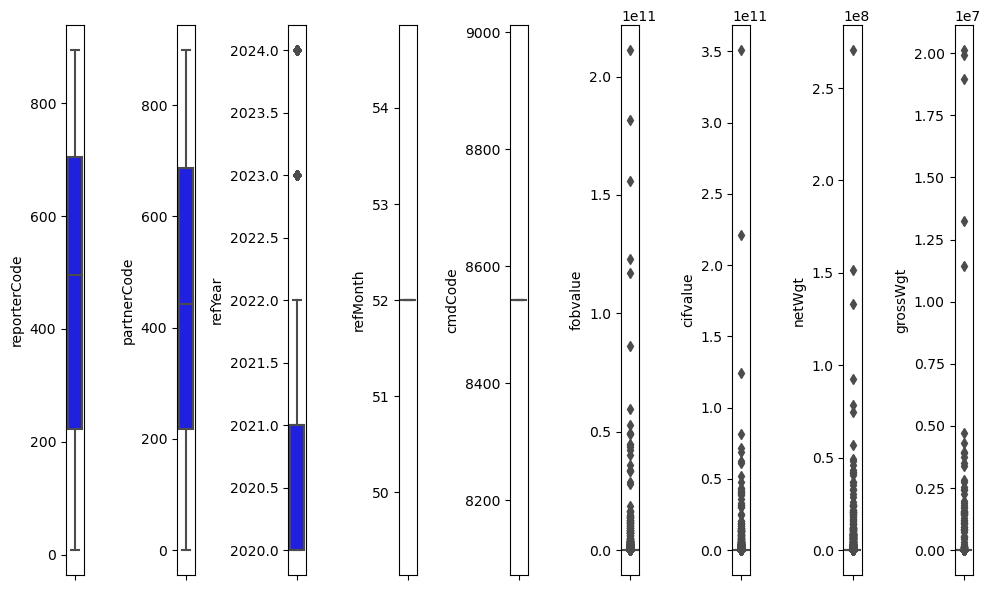

In [41]:
# Check outliers
numerical_columns = df_copy_clean.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(10, 6))
for i in range(0, len(numerical_columns)):
    plt.subplot(1,len(numerical_columns), i+1)
    sns.boxplot(y=df_copy_clean[numerical_columns[i]], color='blue')
    plt.tight_layout()

Since the operations value is the part that has outliers, we will keep the outliers, to keep the original information.

# Data Manipulation

In [49]:
export = df_copy_clean[df_copy_clean["flowCode"] == "X"]
export.sample(5)

,reporterCode,reporterDesc,partnerCode,partnerDesc,refYear,refMonth,flowCode,flowDesc,cmdCode,cmdDesc,fobvalue,cifvalue,netWgt,grossWgt
23272,504,Morocco,0,World,2021,52,X,Export,8542,Electronic integrated circuits,9.824188e+07,0.0,1231309.102,0.0
28032,842,USA,710,South Africa,2021,52,X,Export,8542,Electronic integrated circuits,1.871858e+07,0.0,14106.372,0.0
26444,757,Switzerland,566,Nigeria,2021,52,X,Export,8542,Electronic integrated circuits,9.432150e+04,0.0,97.075,0.0
29548,76,Brazil,558,Nicaragua,2022,52,X,Export,8542,Electronic integrated circuits,1.540000e+02,0.0,0.221,0.0
6794,392,Japan,699,India,2020,52,X,Export,8542,Electronic integrated circuits,7.906383e+07,0.0,57847.299,0.0


In [48]:
imports = df_copy_clean[df_copy_clean["flowCode"] == "M"]
imports.sample(5)

,reporterCode,reporterDesc,partnerCode,partnerDesc,refYear,refMonth,flowCode,flowDesc,cmdCode,cmdDesc,fobvalue,cifvalue,netWgt,grossWgt
4197,276,Germany,352,Iceland,2020,52,M,Import,8542,Electronic integrated circuits,0.00,321896.409,71.00,0.0
41453,834,United Rep. of Tanzania,404,Kenya,2022,52,M,Import,8542,Electronic integrated circuits,29.84,33.140,15.00,0.0
16390,214,Dominican Rep.,862,Venezuela,2021,52,M,Import,8542,Electronic integrated circuits,125.00,149.655,1.25,0.0
11646,757,Switzerland,604,Peru,2020,52,M,Import,8542,Electronic integrated circuits,0.00,2244.391,27.00,0.0
10363,704,Viet Nam,36,Australia,2020,52,M,Import,8542,Electronic integrated circuits,0.00,2131003.715,1985.68,0.0


In [56]:
# Select only columns with float or int data types from df_copy_clean
numeric_df = df_copy_clean.select_dtypes(include=['float64', 'int64'])
numeric_df.head()

,reporterCode,partnerCode,refYear,refMonth,cmdCode,fobvalue,cifvalue,netWgt,grossWgt
0,8,0,2020,52,8542,0.0,1961524.223,0.00,0.0
1,8,156,2020,52,8542,0.0,183993.896,0.00,0.0
2,8,276,2020,52,8542,0.0,21676.351,0.00,0.0
3,8,380,2020,52,8542,0.0,1647454.576,0.00,0.0
4,8,410,2020,52,8542,0.0,4554.309,14.46,0.0


In [ ]:
def check_plot(df, variable):
    # fungsi mengambil kerangka data (df) dan
    # variabel yang diminati sebagai argumen

    # tentukan ukuran gambar
    plt.figure(figsize=(16, 4))

    # histogram
    plt.subplot(1, 3, 1)
    sns.histplot(df[variable], bins=30)
    plt.title('Histogram')

    # plot Q-Q
    plt.subplot(1, 3, 2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.ylabel('Variable quantiles')

    # box plot
    plt.subplot(1, 3, 3)
    sns.boxplot(y=df[variable])
    plt.title('Boxplot')

    plt.show()

c:\Users\Admin\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


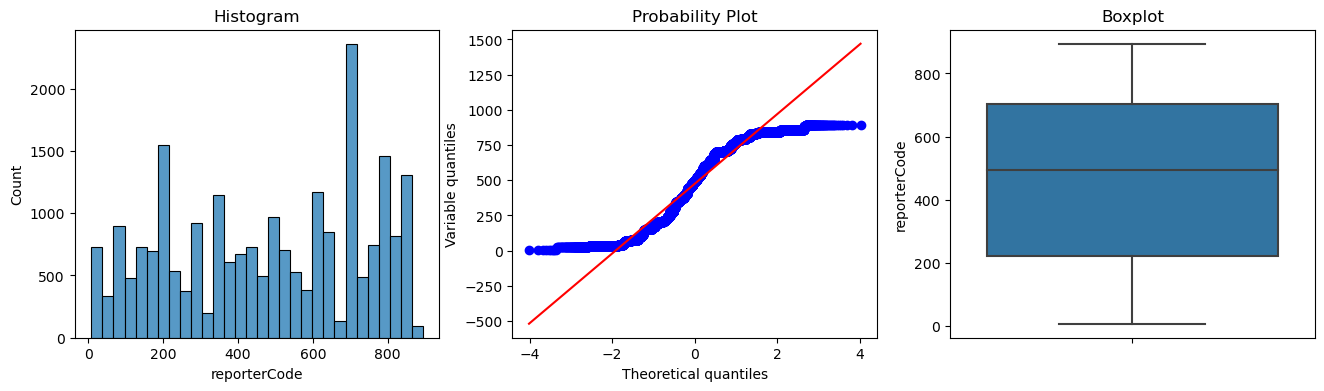

c:\Users\Admin\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


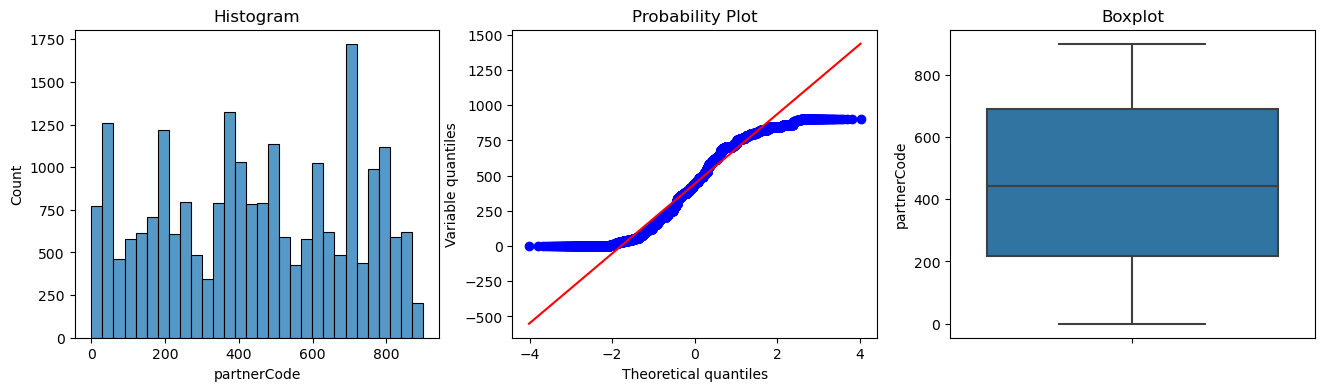

c:\Users\Admin\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


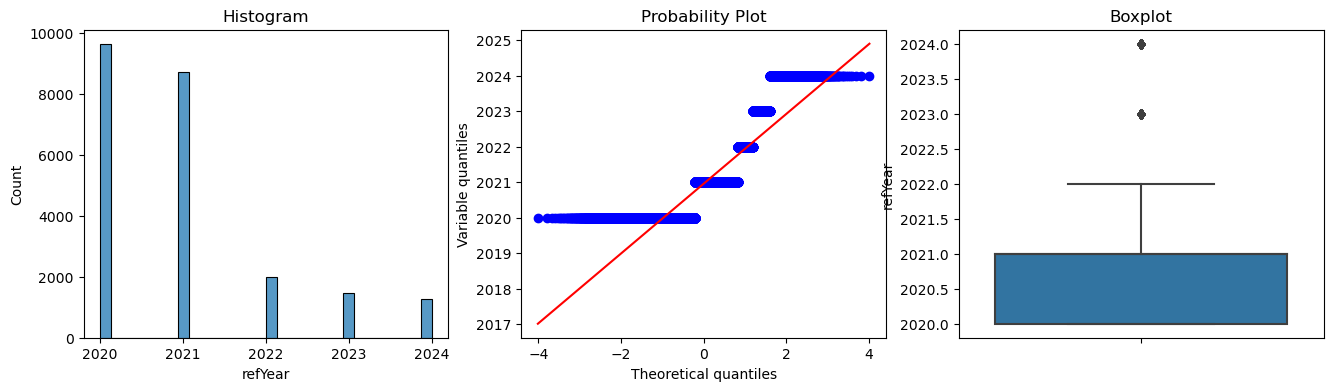

c:\Users\Admin\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


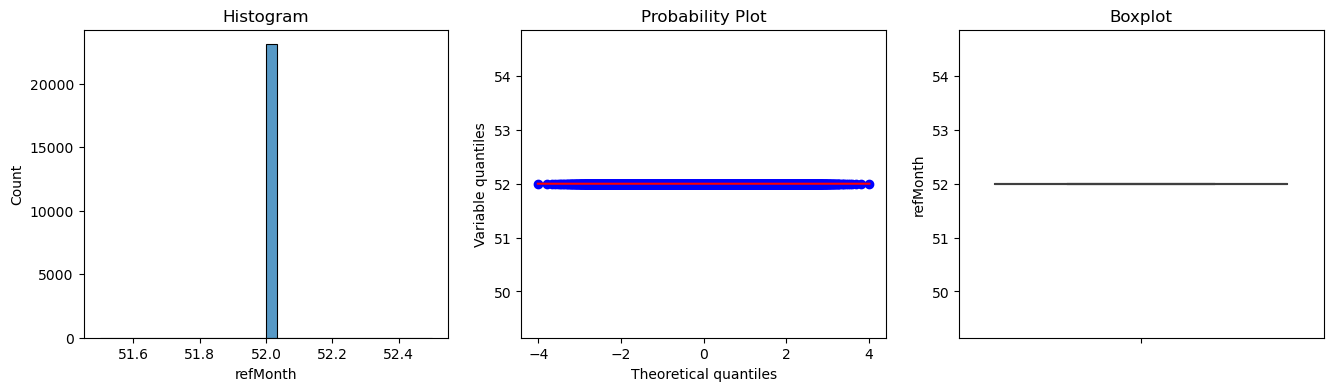

c:\Users\Admin\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


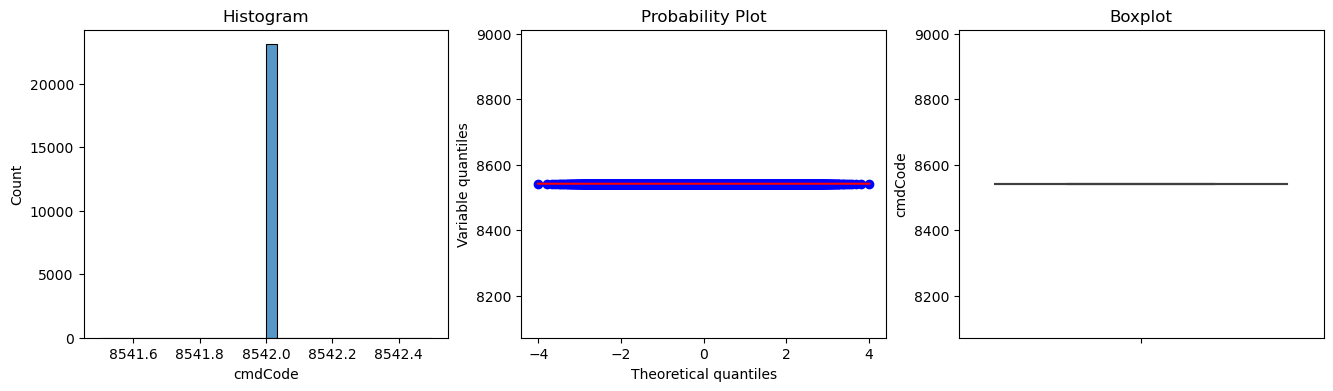

c:\Users\Admin\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


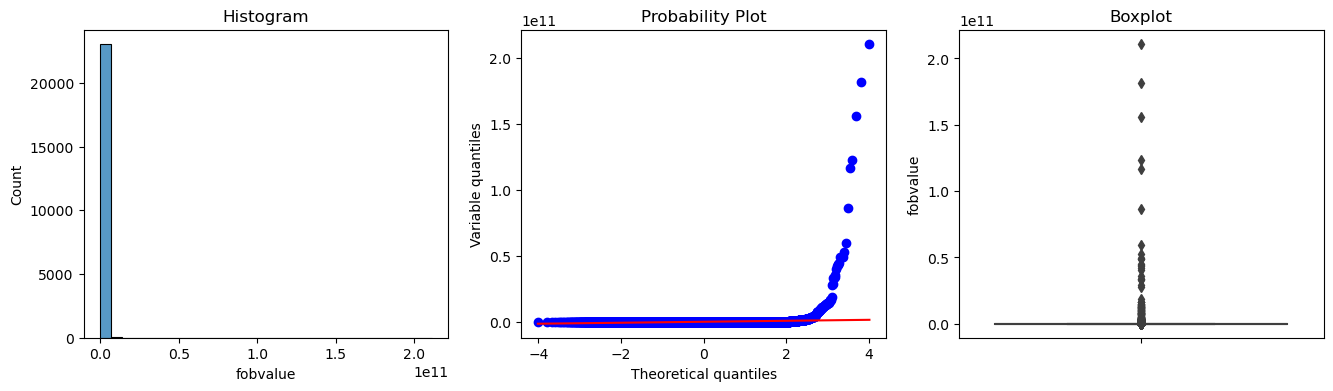

c:\Users\Admin\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


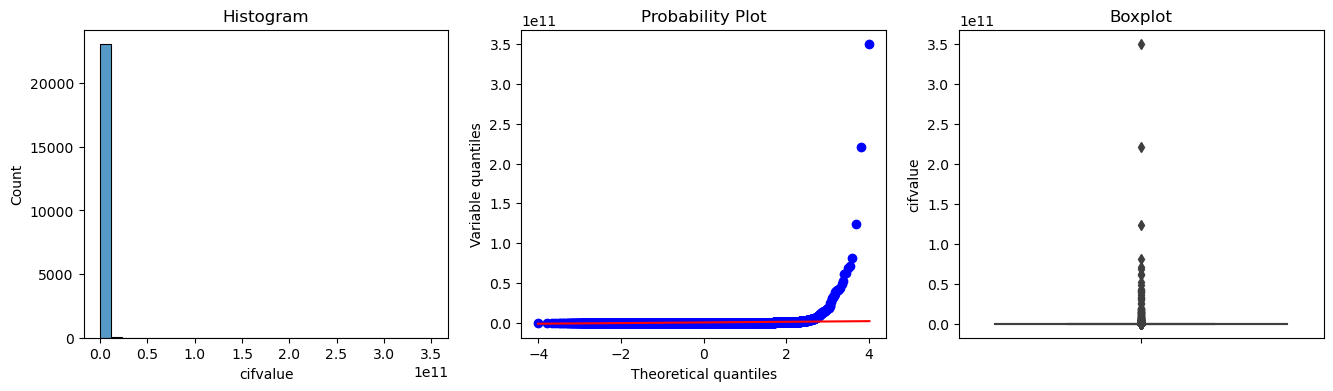

c:\Users\Admin\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


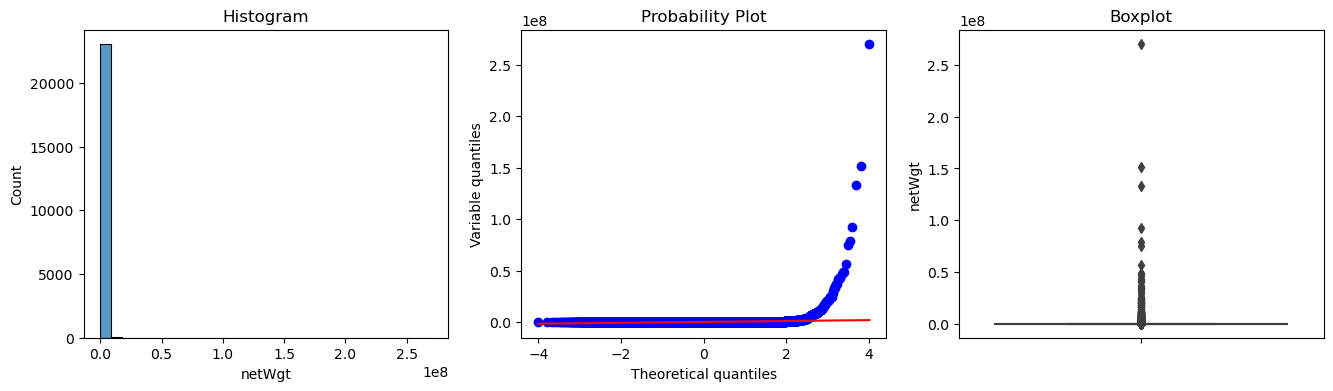

c:\Users\Admin\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


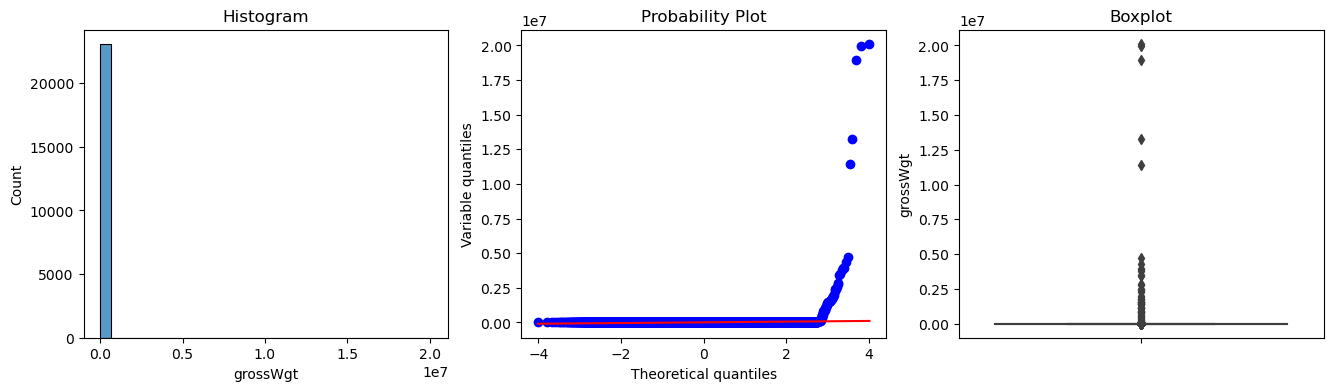

In [57]:
for col in numeric_df:
    check_plot(numeric_df, col)

There is nothing to conclude yet here.

In [59]:
top_countries = df_copy_clean.groupby('partnerDesc')['fobvalue'].sum().sort_values(ascending=False).reset_index()
top_countries.head(10)

,partnerDesc,fobvalue
0,World,1.358248e+12
1,China,4.105902e+11
2,"China, Hong Kong SAR",2.078566e+11
3,"Other Asia, nes",1.273441e+11
4,Rep. of Korea,9.551433e+10
5,Malaysia,8.758729e+10
6,Singapore,8.151765e+10
7,Viet Nam,4.886533e+10
8,Japan,4.366128e+10
9,USA,3.433283e+10


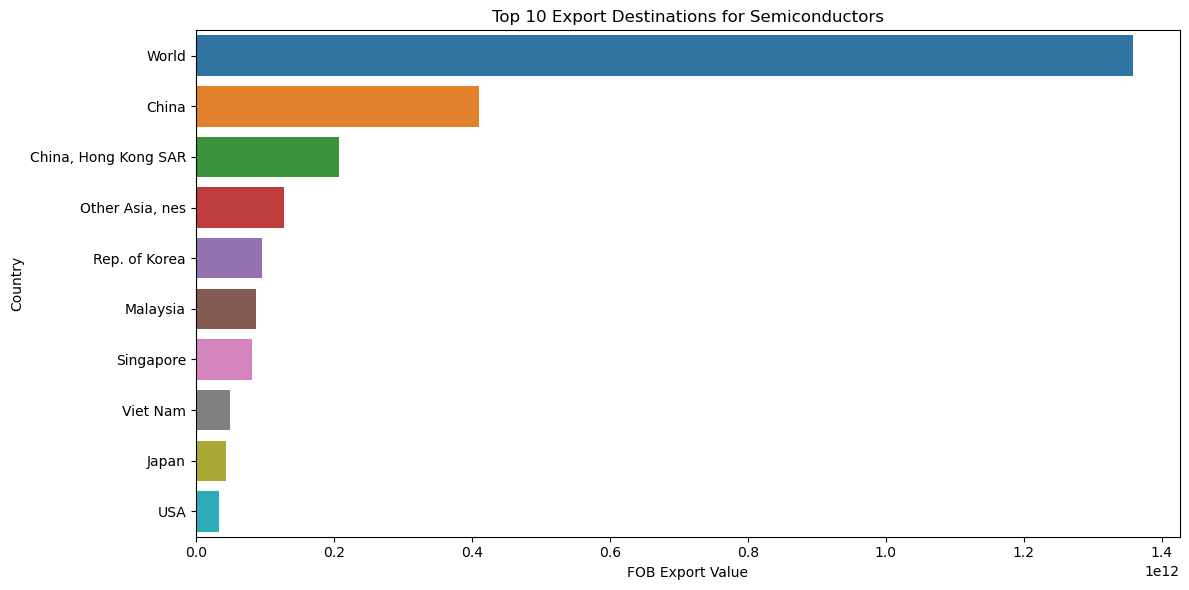

In [60]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_countries.head(10), x='fobvalue', y='partnerDesc')
plt.title('Top 10 Export Destinations for Semiconductors')
plt.xlabel('FOB Export Value')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

<Axes: xlabel='refYear'>

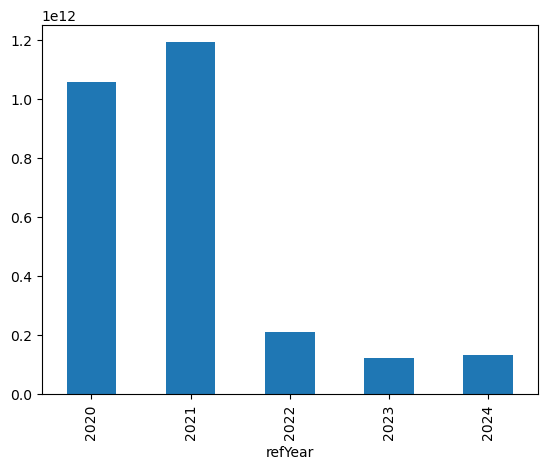

In [62]:
df_copy_clean.groupby(['refYear'])['fobvalue'].sum().plot(kind='bar')